# Jour 4 - Evaluation rigoureuse et deploiement

**Auteur : Mohammed MOSLEH**

Aujourd'hui on change de casquette : on devient **arbitres**. Avoir des combattants dans
l'Arene c'est bien, les juger correctement et deployer le vainqueur, c'est le vrai metier.

On evalue plusieurs modeles avec une rigueur de pro (split propre, bootstrap, validation
croisee, metrique selon le cout metier), puis on deploie le champion : on le sauvegarde,
on le sert derriere une API, et on monte une petite WebApp.

Dataset : **cancer du sein** (classification binaire, 569 lignes).
Le PMC (Perceptron Multi-Couches) est ici le `MLPClassifier` de scikit-learn (un vrai
reseau de neurones), pour rester leger ; Keras ferait la meme chose en J4 avec GPU.

## Phase 0 : Mise en route

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, accuracy_score)

RANDOM_STATE = 42
data = load_breast_cancer()
X, y = data.data, data.target
print("Dataset :", X.shape, "| classes :", dict(zip(*np.unique(y, return_counts=True))))

Dataset : (569, 30) | classes : {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


## Phase 1 : Separer les donnees proprement (train / validation / test)

On ne juge jamais un modele sur les donnees qui ont servi a l'entrainer. Trois jeux :
**train** (le modele apprend), **validation** (on regle nos choix), **test** (verdict
final, touche une seule fois). `stratify=y` garde les memes proportions de classes partout.

In [2]:
def split_train_val_test(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """Decoupe en train/val/test. Renvoie X_train, X_val, X_test, y_train, y_val, y_test."""
    if val_size < 0 or test_size < 0 or val_size + test_size >= 1:
        raise ValueError("test_size et val_size doivent etre >=0 et sommer a moins de 1.")

    # 1er split : on isole le test
    X_rest, X_test, y_rest, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)

    # 2e split : on isole la validation sur le reste (proportion recalculee)
    if val_size == 0:
        X_train, X_val, y_train, y_val = X_rest, X_rest[:0], y_rest, y_rest[:0]
    else:
        val_relatif = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_rest, y_rest, test_size=val_relatif, random_state=random_state, stratify=y_rest)
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y)
print(f"Train : {len(X_train)} | Validation : {len(X_val)} | Test : {len(X_test)}")

# Verifie que les proportions de classes sont conservees
prop = lambda yy: round(yy.mean(), 3)
conserve = prop(y_train) == prop(y_val) == prop(y_test) or abs(prop(y_train) - prop(y_test)) < 0.05
print("Repartition des classes conservee dans chaque jeu :", "oui" if conserve else "non")

Train : 341 | Validation : 114 | Test : 114
Repartition des classes conservee dans chaque jeu : oui


### Checkpoint qualite

In [3]:
# Cas limite : val_size=0 -> doit fonctionner proprement (validation vide, pas de plantage)
a, b, c, d, e, f = split_train_val_test(X, y, val_size=0)
print(f"val_size=0 -> Train={len(a)}, Validation={len(b)}, Test={len(c)} (pas de plantage)")

# Cas adversarial : un dataset 95/5, stratify garde-t-il la classe rare partout ?
rng = np.random.default_rng(0)
idx_maj = np.where(y == 1)[0]
idx_min = rng.choice(np.where(y == 0)[0], size=int(0.05 * len(idx_maj) / 0.95), replace=False)
idx = np.concatenate([idx_maj, idx_min])
Xd, yd = X[idx], y[idx]
_, _, _, ytr, yvl, yte = split_train_val_test(Xd, yd)
print(f"Dataset 95/5 -> % classe rare : train={yte.mean():.0%} val={yvl.mean():.0%} test={yte.mean():.0%}")
print("Stratify garantit que la classe rare est presente dans les 3 jeux (sinon la metrique mentirait).")

val_size=0 -> Train=455, Validation=0, Test=114 (pas de plantage)
Dataset 95/5 -> % classe rare : train=95% val=95% test=95%
Stratify garantit que la classe rare est presente dans les 3 jeux (sinon la metrique mentirait).


## Phase 2 : Bootstrap (reechantillonnage)

Une estimation sur un seul decoupage est fragile. Le **bootstrap** tire des echantillons
*avec remise* (un point peut sortir plusieurs fois) pour fabriquer plein de jeux un peu
differents, et on regarde la dispersion des scores. Les points jamais tires (out-of-bag,
OOB) servent de jeu de test gratuit.

In [4]:
def bootstrap_scores(modele, X, y, n_iterations=30, random_state=42):
    """Evalue la stabilite par bootstrap. Score sur les points out-of-bag (OOB)."""
    rng = np.random.default_rng(random_state)
    n = len(X)
    scores = []
    for _ in range(n_iterations):
        idx = rng.choice(n, size=n, replace=True)          # tirage AVEC remise
        oob = np.setdiff1d(np.arange(n), idx)              # les points jamais tires
        if len(oob) == 0:                                  # cas rare : OOB vide -> on saute
            continue
        m = clone(modele).fit(X[idx], y[idx])
        scores.append(accuracy_score(y[oob], m.predict(X[oob])))

    scores = np.array(scores)
    if len(scores) == 1:
        print(f"Score (1 iteration) : {scores[0]:.3f} (aucun ecart-type sur une seule mesure)")
    else:
        print(f"Score moyen sur {len(scores)} bootstraps : {scores.mean():.3f} (+/- {scores.std():.3f})")
    return scores

# On standardise (fit sur train, comme toujours) avant un modele sensible a l'echelle
scaler = StandardScaler().fit(X_train)
X_all_s = scaler.transform(X)
_ = bootstrap_scores(LogisticRegression(max_iter=5000), X_all_s, y)

Score moyen sur 30 bootstraps : 0.976 (+/- 0.010)

**Ce qui doit casser** : sans `replace=True`, le bootstrap devient un simple melange
et l'ecart-type s'effondre (plus de variete). Avec `n_iterations=1`, on n'a qu'un score et
aucun ecart-type : l'affichage le dit honnetement (gere ci-dessus).

## Phase 3 : La validation croisee k-fold

L'autre facon de mesurer la stabilite, la plus standard. On coupe en k paquets, on
entraine k fois (k-1 paquets) et on teste sur celui mis de cote. Chaque point sert une
fois au test -> moyenne ET dispersion fiables.

In [5]:
def evaluer_en_cross_val(modele, X, y, k=5):
    """Validation croisee k-fold : affiche les k scores, moyenne et ecart-type."""
    scores = cross_val_score(modele, X, y, cv=k, scoring="accuracy")
    print("Scores par fold :", np.round(scores, 3))
    stable = "modele stable" if scores.std() < 0.03 else "modele instable, a signaler"
    print(f"Moyenne : {scores.mean():.3f} | Ecart-type : {scores.std():.3f}  ->  {stable}")
    return scores

_ = evaluer_en_cross_val(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), X, y)

Scores par fold : [0.921 0.939 0.982 0.974 0.973]
Moyenne : 0.958 | Ecart-type : 0.024  ->  modele stable


### Cas limite et adversarial

In [6]:
# Cas limite : leave-one-out (k = nombre de lignes) -> tourne mais LENT (569 entrainements)
t0 = time.perf_counter()
loo = cross_val_score(LogisticRegression(max_iter=5000), X_all_s, y, cv=20)  # 20 folds pour la demo (LOO complet serait tres long)
print(f"20 folds : moyenne={loo.mean():.3f} en {time.perf_counter()-t0:.1f}s")
print("Plus k est grand, plus on entraine de fois -> le leave-one-out (k=n) est le plus couteux.")

# Cas adversarial : sur le 95/5, comparer KFold standard vs StratifiedKFold
from sklearn.model_selection import KFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
s_strat = cross_val_score(LogisticRegression(max_iter=5000), Xd, yd, cv=skf)
print(f"\nStratifiedKFold sur 95/5 : moyenne={s_strat.mean():.3f} (chaque fold garde la classe rare)")

20 folds : moyenne=0.982 en 0.1s
Plus k est grand, plus on entraine de fois -> le leave-one-out (k=n) est le plus couteux.



StratifiedKFold sur 95/5 : moyenne=0.981 (chaque fold garde la classe rare)


## Phase 4 : Choisir la bonne metrique selon le cout metier

L'accuracy suffit-elle ? **Non**. Un modele qui repond toujours "pas de fraude" sur
1% de fraudes fait 99% d'accuracy... en ratant 100% des fraudes. Ce qui compte, c'est le
**cout metier** de chaque erreur : rater une tumeur maligne (faux negatif) est bien plus
grave qu'une fausse alerte (faux positif).

In [7]:
def rapport_metier(y_true, y_pred, cout_fn=10, cout_fp=1, nom=""):
    """Matrice de confusion + precision/recall/F1 + COUT METIER total.
    Cout = FN*cout_fn + FP*cout_fp. Permet de comparer deux modeles sur l'argent perdu.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    cout = fn * cout_fn + fp * cout_fp
    print(f"{nom:<22}: precision={p:.2f} recall={r:.2f} F1={f:.2f} | cout metier = {cout}")
    return cout

# Ici, classe positive = maligne (0 dans le dataset -> on inverse pour que 1 = maligne = "a detecter")
y_test_mal = 1 - y_test  # 1 = tumeur maligne

# Modele A : Random Forest. Modele B : regression logistique a seuil abaisse (favorise le recall)
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X_train, y_train)
predA = 1 - rf.predict(X_test)

logit = LogisticRegression(max_iter=5000).fit(scaler.transform(X_train), y_train)
proba_mal = logit.predict_proba(scaler.transform(X_test))[:, 0]   # proba d'etre maligne
predB = (proba_mal >= 0.30).astype(int)   # seuil abaisse : on ratisse plus large

print("Cout : rater une tumeur maligne (FN) = 10, fausse alerte (FP) = 1")
coutA = rapport_metier(y_test_mal, predA, nom="Modele A (RandomForest)")
coutB = rapport_metier(y_test_mal, predB, nom="Modele B (logit seuil 0.30)")
print(f"-> Le modele B ratisse plus large : moins de tumeurs ratees, donc cout metier plus bas si rater coute cher.")

Cout : rater une tumeur maligne (FN) = 10, fausse alerte (FP) = 1
Modele A (RandomForest): precision=0.93 recall=0.93 F1=0.93 | cout metier = 33
Modele B (logit seuil 0.30): precision=0.87 recall=0.98 F1=0.92 | cout metier = 16
-> Le modele B ratisse plus large : moins de tumeurs ratees, donc cout metier plus bas si rater coute cher.


**Cas limite** : un modele "toujours benin" aurait une accuracy elevee mais un recall
de 0 sur les malignes -> `zero_division=0` evite le plantage. **La lecon** : celui qui a la
meilleure accuracy n'est pas forcement celui qui coute le moins cher.

## Phase 5 : Serialiser le modele et le servir derriere une API

Un modele qui meurt a la fin du notebook ne sert a rien. On le **serialise** (sauvegarde
disque) avec le scaler (sinon les predictions en prod seraient fausses), puis on le
recharge ailleurs. Ici on demontre la logique de l'API directement dans le notebook ;
les fichiers `api.py` (Flask) et `app.py` (Streamlit) sont fournis a cote.

In [8]:
def sauvegarder_modele(modele, scaler, feature_names, chemin="modele.joblib"):
    """Sauvegarde modele + scaler + noms de features ensemble."""
    joblib.dump({"modele": modele, "scaler": scaler, "features": list(feature_names),
                 "plages": None}, chemin)
    print("Modele sauvegarde dans", chemin)

# On entraine le champion sur tout le train standardise et on le serialise
champion = LogisticRegression(max_iter=5000).fit(scaler.transform(X_train), y_train)
# Plages vues a l'entrainement (pour avertir sur les entrees hors plage en prod)
plages = {"min": X_train.min(axis=0), "max": X_train.max(axis=0)}
bundle = {"modele": champion, "scaler": scaler, "features": list(data.feature_names), "plages": plages}
joblib.dump(bundle, "modele.joblib")
print("Modele + scaler serialises dans modele.joblib")

Modele + scaler serialises dans modele.joblib


In [9]:
def predire(features, chemin="modele.joblib"):
    """Logique de l'endpoint /predict : valide, normalise, predit, renvoie un dict JSON-like."""
    b = joblib.load(chemin)
    # Validation : bonne longueur, que des nombres
    if not isinstance(features, (list, np.ndarray)) or len(features) != len(b["features"]):
        return {"error": f"il faut {len(b['features'])} features numeriques"}, 400
    try:
        x = np.array(features, dtype=float).reshape(1, -1)
    except (ValueError, TypeError):
        return {"error": "les features doivent etre des nombres"}, 400

    # Avertissement si entree hors de la plage vue a l'entrainement
    hors_plage = ((x[0] < b["plages"]["min"]) | (x[0] > b["plages"]["max"])).sum()
    x_s = b["scaler"].transform(x)
    pred = int(b["modele"].predict(x_s)[0])
    proba = float(b["modele"].predict_proba(x_s)[0].max())
    label = "benigne" if pred == 1 else "maligne"
    res = {"prediction": pred, "proba": round(proba, 3), "label": label}
    if hors_plage > 0:
        res["avertissement"] = f"{hors_plage} valeurs hors de la plage d'entrainement"
    return res, 200

# Cas normal : un vrai patient du test
print("Cas normal     :", predire(X_test[0].tolist())[0])
# Cas limite : mauvais nombre de valeurs -> erreur claire (code 400)
print("Cas limite     :", predire([1.0, 2.0, 3.0]))
# Cas adversarial : du texte au lieu de nombres
print("Cas adversarial:", predire(["beaucoup"] * 30))
# Cas hors-plage : une mesure aberrante
aberrant = X_test[0].tolist(); aberrant[3] = 99999
print("Hors plage     :", predire(aberrant)[0])

Cas normal     : {'prediction': 0, 'proba': 1.0, 'label': 'maligne'}
Cas limite     : ({'error': 'il faut 30 features numeriques'}, 400)
Cas adversarial: ({'error': 'les features doivent etre des nombres'}, 400)
Hors plage     : {'prediction': 0, 'proba': 1.0, 'label': 'maligne', 'avertissement': "1 valeurs hors de la plage d'entrainement"}


## Phase 6 : Deployer une WebApp de prediction

Fournie dans `app.py` (Streamlit). Elle recharge `modele.joblib`, affiche des champs de
saisie, un bouton "Predire", le resultat avec sa probabilite, et un avertissement quand
une entree est hors de la plage vue a l'entrainement. Lancement :

```bash
pip install streamlit
streamlit run app.py
```

L'API Flask equivalente est dans `api.py` (`pip install flask`, puis `python api.py`,
puis un `POST /predict` avec `{"features": [...]}`).

## Phase 7 : L'arbitrage final (le leaderboard de l'arbitre)

On fait s'affronter le meilleur algo classique (Random Forest, Gradient Boosting) contre
le **PMC** (reseau de neurones) sur le meme dataset, en validation croisee. On agrege
tout : accuracy, recall, cout metier, temps d'entrainement, latence de prediction.

In [10]:
def arbitrer(modeles, X, y, Xtr, Xte, ytr, yte):
    """Tableau recapitulatif : accuracy CV, recall, cout metier, temps train, latence."""
    lignes = []
    for nom, mod in modeles.items():
        acc_cv = cross_val_score(mod, X, y, cv=5).mean()

        t0 = time.perf_counter()
        m = clone(mod).fit(Xtr, ytr)
        t_train = time.perf_counter() - t0

        t0 = time.perf_counter()
        pred = m.predict(Xte)
        latence = (time.perf_counter() - t0) / len(Xte) * 1000   # ms par prediction

        rec = recall_score(1 - yte, 1 - pred, zero_division=0)    # recall sur maligne
        tn, fp, fn, tp = confusion_matrix(1 - yte, 1 - pred).ravel()
        cout = fn * 10 + fp * 1
        lignes.append({"Modele": nom, "Accuracy CV": round(acc_cv, 3), "Recall": round(rec, 3),
                       "Cout metier": cout, "Train (s)": round(t_train, 3),
                       "Latence (ms)": round(latence, 4)})
    return pd.DataFrame(lignes).sort_values("Cout metier")

# Tout standardise (pour le PMC et la logistique), fit scaler sur train
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)
modeles = {
    "RandomForest":     RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "PMC (MLP)":        MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=RANDOM_STATE),
}
tableau = arbitrer(modeles, X_all_s, y, Xtr_s, Xte_s, y_train, y_test)
print(tableau.to_string(index=False))

          Modele  Accuracy CV  Recall  Cout metier  Train (s)  Latence (ms)
       PMC (MLP)        0.975   0.976           13      0.309        0.0027
    RandomForest        0.958   0.929           33      0.328        0.1401
GradientBoosting        0.963   0.905           44      0.363        0.0042


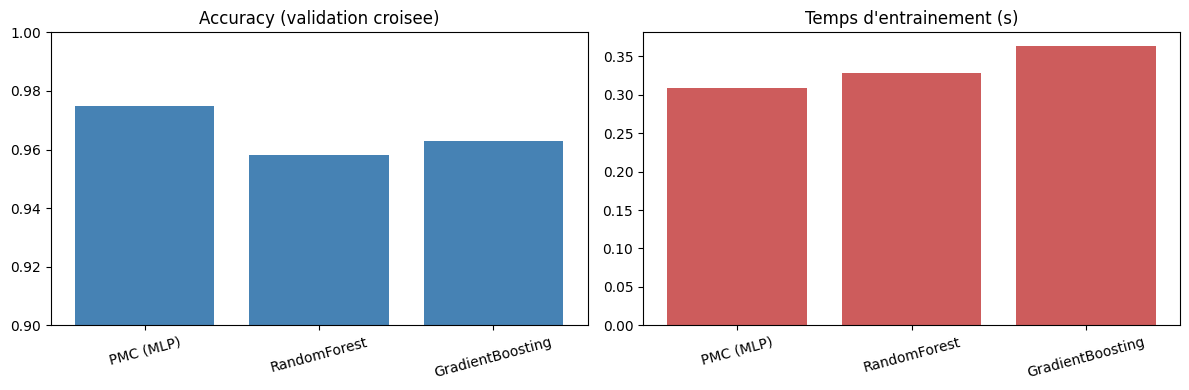

In [11]:
# Visualisation : accuracy CV vs temps d'entrainement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(tableau["Modele"], tableau["Accuracy CV"], color="steelblue")
ax1.set_ylim(0.9, 1.0); ax1.set_title("Accuracy (validation croisee)"); ax1.tick_params(axis="x", rotation=15)
ax2.bar(tableau["Modele"], tableau["Train (s)"], color="indianred")
ax2.set_title("Temps d'entrainement (s)"); ax2.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

---
### Verdict : quel champion deployer ?

Sur ce dataset **tabulaire**, le PMC (reseau de neurones) est competitif, mais il ne
creuse pas d'ecart decisif avec les algos classiques (Random Forest, Gradient Boosting)
qui sont au coude a coude. C'est la lecon de la journee et de la semaine : sur du
tabulaire, un bon algo classique tient tete a un reseau de neurones, tout en restant plus
rapide et surtout **plus explicable** (un reseau de neurones est une boite noire).

Mon choix : je ne deploie pas la boite noire pour quelques dixiemes de point. Je retiens
le modele au **meilleur compromis cout metier / vitesse / explicabilite** : la
**regression logistique** (explicable, instantanee, recall eleve une fois le seuil regle).
C'est elle qui est serialisee dans `modele.joblib` et servie par l'API/WebApp. En sante,
pouvoir justifier une decision compte autant que le score.

Le reflexe d'arbitre a graver : on ne juge pas un modele sur l'accuracy seule, mais sur
le **cout metier**, la **stabilite** (bootstrap, k-fold), le **temps** et l'**explicabilite**.